In [ ]:
!pip install gymnasium[classic_control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.0 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import display
from collections import deque, namedtuple
import random

# Initialize the environment
env = gym.make('CartPole-v1', render_mode='rgb_array')

# Get dimensions of state and action spaces
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
state_tensor = torch.tensor(env.observation_space.sample()).unsqueeze(0)

print(f'State size: {state_size}')
print(f'Action size: {action_size}')
print(f'random state: {env.observation_space.sample()}')
print(f'random action: {env.action_space.sample()}')
print(type(env.observation_space.sample()))
print(state_tensor)
print(state_tensor.dtype)

State size: 4
Action size: 2
random state: [-3.6182504   1.0259545   0.21667509  2.1758664 ]
random action: 1
<class 'numpy.ndarray'>
tensor([[ 1.5282,  0.5528, -0.2327,  1.8649]])
torch.float32


In [ ]:
# Define the Deep Q-network
class DQN(nn.Module):
  def __init__(self, n_observations, hidden_size, n_actions):
    super().__init__()
    self.fc1 = nn.Linear(n_observations, hidden_size)
    self.relu1 = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, hidden_size)
    self.relu2 = nn.ReLU()
    self.fc3 = nn.Linear(hidden_size, n_actions)

  def forward(self, X):
    X = self.fc1(X)
    X = self.relu1(X)
    X = self.fc2(X)
    X = self.relu2(X)
    X = self.fc3(X)
    return X

In [ ]:
# Build replay buffer(store transitions & sample randomly from them)
Transition = namedtuple('Transition', ['state', 'action', 'reward', 'next_state', 'done'])
class ReplayBuffer():
  def __init__(self, capacity):
    self.buffer = deque([], maxlen=capacity)   # define the buffer
  def push(self, *args):
    self.buffer.append(Transition(*args))  # add transition into buffer
  def sample(self, batch_size):
    return random.sample(self.buffer, batch_size)  # sample randomly from buffer
  def __len__(self):
    return len(self.buffer)

In [ ]:
# Hyperparameters
hidden_size = 128
batch_size = 128
gamma = 0.99
max_epsilon = 0.9
min_epsilon = 0.01
decay_rate = 2500
tau = 0.005
lr = 3e-4

In [ ]:
# Build target network (solving moving target problem)
policy_net = DQN(state_size, hidden_size, action_size)
target_net = DQN(state_size, hidden_size, action_size)

target_net.load_state_dict(policy_net.state_dict())

<All keys matched successfully>

In [ ]:
# Use epsilon-greedy policy to select action
def epsilon_greedy(state, epsilon):
  sample = random.random()
  if sample > epsilon:  # exploitation
    with torch.no_grad():
      action = policy_net(state).max(1).indices.view(1,1)
  else:  # exploration
    action = torch.tensor([[env.action_space.sample()]])
  return action

# choose optimizer & buffer
optimizer = optim.Adam(policy_net.parameters(), lr=lr, amsgrad=True)
memory = ReplayBuffer(10000)

In [ ]:
# Optimization
def optimize_model():
  if len(memory) < batch_size:
    return
  # get one batch
  batch = memory.sample(batch_size)
  # extract state, action, reward, next_state from batch
  state_batch = torch.cat(list(map(lambda lst: lst[0], batch)), dim=0)
  action_batch = torch.cat(list(map(lambda lst: lst[1], batch)), dim=0)
  reward_batch = torch.cat(list(map(lambda lst: lst[2], batch)), dim=0)
  next_state_batch = torch.cat(list(map(lambda lst: lst[3], batch)), dim=0)
  done_batch = torch.cat(list(map(lambda lst: lst[4], batch)), dim=0)
  # run Deep Q-network
  Q_value = policy_net(state_batch).gather(1, action_batch)
  with torch.no_grad():
    Q_target = target_net(next_state_batch)
  # TD target
  TD_target = reward_batch + gamma * torch.max(Q_target, dim=1).values * (1.0 - done_batch.float()) # broadcasting machenism for tensor
  # define Huber loss
  criterion = nn.SmoothL1Loss()
  loss = criterion(Q_value, TD_target.unsqueeze(1))
  # optimize the model
  optimizer.zero_grad()
  loss.backward()
  torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
  optimizer.step()

In [ ]:
n_episode = 600
max_step = 500
episode_durations = []
# Training Loop
steps_done = 0
for episode in range(n_episode):
  # initialize the envrionment
  state, info = env.reset()
  state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
  for step in range(max_step):
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-1 * steps_done / decay_rate)
    steps_done += 1
    action = epsilon_greedy(state, epsilon)
    next_state, reward, terminated, truncated, _ = env.step(action.item())  # gym env requires a scalar action
    done = terminated or truncated
    reward = torch.tensor([reward], dtype=torch.float32)
    done = torch.tensor([done], dtype=bool)
    next_state = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
    # save the transition into replaybuffer
    memory.push(state, action, reward, next_state, done)
    # move to next state
    state = next_state
    # Optimize the model
    if len(memory) >= batch_size:  # replaybuffer should be larger than batch_size
        optimize_model()
        # soft update for target network after one optimization step
        policy_net_state_dict = policy_net.state_dict()
        target_net_state_dict = target_net.state_dict()
        for key in policy_net_state_dict:
          target_net_state_dict[key] = tau * policy_net_state_dict[key] + (1 - tau) * target_net_state_dict[key]
        target_net.load_state_dict(target_net_state_dict)
    if done.item():
      episode_durations.append(step + 1)
      break
  # check if it is training
  if episode % 50 == 0:
    if len(episode_durations) > 0:
        # Get the durations for the last 50 episodes, or fewer if not enough episodes have passed
        recent_durations = episode_durations[-50:]
        avg_duration = np.mean(recent_durations)
        print(f"Episode {episode}, Average Duration (last {len(recent_durations)} episodes): {avg_duration:.2f}")
    else:
        print(f"Episode {episode}, No durations recorded yet.")

Episode 0, Average Duration (last 1 episodes): 17.00
Episode 50, Average Duration (last 50 episodes): 18.14
Episode 100, Average Duration (last 50 episodes): 174.98
Episode 150, Average Duration (last 50 episodes): 143.80
Episode 200, Average Duration (last 50 episodes): 144.74
Episode 250, Average Duration (last 50 episodes): 277.50
Episode 300, Average Duration (last 50 episodes): 390.10
Episode 350, Average Duration (last 50 episodes): 500.00
Episode 400, Average Duration (last 50 episodes): 498.24
Episode 450, Average Duration (last 50 episodes): 500.00
Episode 500, Average Duration (last 50 episodes): 492.58
Episode 550, Average Duration (last 50 episodes): 500.00


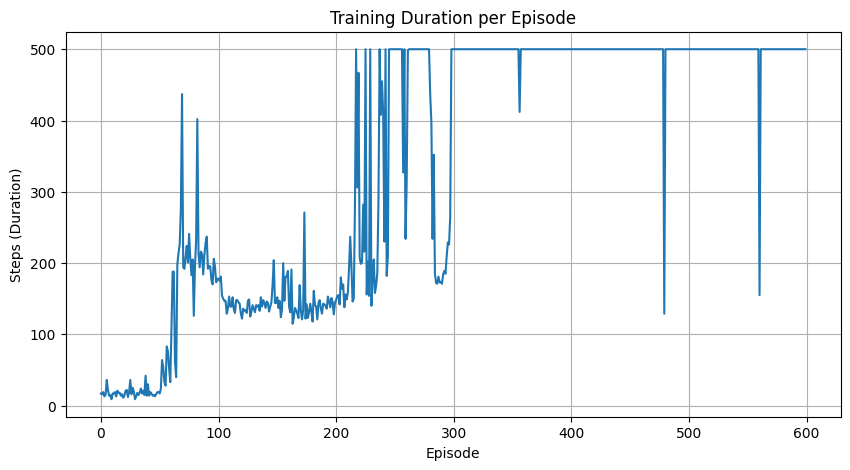

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(episode_durations)
plt.title('Training Duration per Episode')
plt.xlabel('Episode')
plt.ylabel('Steps (Duration)')
plt.grid(True)
plt.show()

In [ ]:
if episode_durations:
    average_duration_all_episodes = np.mean(episode_durations)
    print(f"Average duration over all {len(episode_durations)} episodes: {average_duration_all_episodes:.2f}")
else:
    print("No episode durations recorded yet.")

Average duration over all 600 episodes: 343.63


In [ ]:
from torch._prims_common import dtype_to_type
def test_model(n_test_episodes=10):
    for i in range(n_test_episodes):
        state, _ = env.reset()
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        total_reward = 0
        done = False

        while not done:
            # Pure exploitation: No epsilon-greedy
            with torch.no_grad():
                action = policy_net(state).max(1).indices.view(1, 1)

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            state = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
            total_reward += reward
            done = terminated or truncated

        print(f"Test Episode {i+1}: Total Reward = {total_reward}")

test_model()

Test Episode 1: Total Reward = 500.0
Test Episode 2: Total Reward = 500.0
Test Episode 3: Total Reward = 500.0
Test Episode 4: Total Reward = 500.0
Test Episode 5: Total Reward = 500.0
Test Episode 6: Total Reward = 500.0
Test Episode 7: Total Reward = 500.0
Test Episode 8: Total Reward = 500.0
Test Episode 9: Total Reward = 500.0
Test Episode 10: Total Reward = 500.0


In [ ]:
import imageio.v2 as imageio
from IPython.display import HTML, display

def generate_video(env, policy_net, filename='cartpole_trained_agent.gif', n_test_episodes=1, duration_seconds=5, fps=None):
    frames = []
    for i in range(n_test_episodes):
        state, _ = env.reset()
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        done = False

        while not done:
            frames.append(env.render())
            with torch.no_grad():
                action = policy_net(state).max(1).indices.view(1, 1)

            next_state, _, terminated, truncated, _ = env.step(action.item())
            state = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
            done = terminated or truncated

    # Use provided fps if available, otherwise calculate based on duration
    if fps is None:
        if len(frames) > 0 and duration_seconds > 0:
            fps = len(frames) / duration_seconds
        else:
            fps = 30 # Default fps if no frames or duration is zero

    imageio.mimsave(filename, frames, fps=fps)
    print(f"Video saved as {filename} with a duration of approximately {len(frames) / fps:.2f} seconds and {fps:.2f} fps")

    # Display the GIF in the notebook
    display(HTML(f'<img src="{filename}">'))

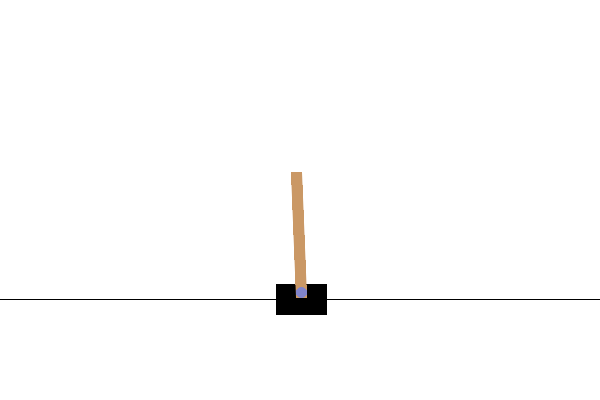

In [ ]:
from IPython.display import Image

# Assuming the GIF is saved as 'cartpole_trained_agent.gif'
# And it's in the current working directory (/content/)
Image(filename='cartpole_trained_agent.gif')